In [1]:
# All the imports
import os
import numpy as np
import re
import csv
from collections import defaultdict
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# TODO: Remove this cell for submission (should use the local directory)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# TODO: Put the path to the directory of the mle target params
base_dir = '/content/drive/MyDrive/parameter fitting/ParFit/target_params_all'
# base_dir = os.path.join('.', 'output_data', 'target_params', 'mle')

In [4]:
output_dir = os.path.join(base_dir, 'output')

In [5]:
train_seed = 321
query_seed = 993

### Review the files and directories

In [6]:
# Walk through all subdirectories and list files
for root, dirs, files in os.walk(base_dir):
    for file in files:
        full_path = os.path.join(root, file)
        print(full_path)

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=103.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=105.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=106.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=104.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=107.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.35_seed=108.csv
/content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/chung-lu-pl/chung-lu-pl_n=6000_d=10_beta=3.9_seed=100.csv
/content/drive/MyDrive/parameter fitting/ParFit

In [7]:
pattern = re.compile(
    r'(?P<graph_type>[^/]+)/[^/]+_n=(?P<n>\d+)_d=(?P<d>[\d.]+)'
    r'(?:_t=(?P<t>[\d.]+))?(?:_beta=(?P<beta>[\d.]+))?_seed=(?P<seed>\d+)\.csv$'
)

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, base_dir)
            match = pattern.search(rel_path)
            if match:
                data = match.groupdict()
                print(f"Path: {full_path}")
                print(f"  Graph type: {data['graph_type']}")
                print(f"  n: {data['n']}")
                print(f"  d: {data['d']}")
                print(f"  t: {data.get('t')}")
                print(f"  beta: {data.get('beta')}")
                print(f"  seed: {data['seed']}")
                print()


Streaming output truncated to the last 5000 lines.
Path: /content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/mle/chung-lu-pl/chung-lu-pl_n=5331_d=3_beta=3.901_seed=321.csv
  Graph type: chung-lu-pl
  n: 5331
  d: 3
  t: None
  beta: 3.901
  seed: 321

Path: /content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/mle/chung-lu-pl/chung-lu-pl_n=6261_d=9_beta=2.38_seed=321.csv
  Graph type: chung-lu-pl
  n: 6261
  d: 9
  t: None
  beta: 2.38
  seed: 321

Path: /content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/mle/chung-lu-pl/chung-lu-pl_n=2087_d=9_beta=3.615_seed=321.csv
  Graph type: chung-lu-pl
  n: 2087
  d: 9
  t: None
  beta: 3.615
  seed: 321

Path: /content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle/mle/chung-lu-pl/chung-lu-pl_n=1996_d=6_beta=1.845_seed=321.csv
  Graph type: chung-lu-pl
  n: 1996
  d: 6
  t: None
  beta: 1.845
  seed: 321

Path: /content/drive/MyDrive/parameter fitting/ParFit/target_params_all/mle

### Create the result dict
Dict where the keys are tuple of features (features of the largest connected component in the graph). The values are the parameters, taken from the filename

In [8]:
# Regex pattern to extract metadata from filename
pattern = re.compile(
    r'(?P<graph_type>[^/]+)/[^/]+_n=(?P<n>\d+)_d=(?P<d>[\d.]+)'
    r'(?:_t=(?P<t>[\d.]+))?(?:_beta=(?P<beta>[\d.]+))?_seed=(?P<seed>\d+)\.csv$'
)

# Initialize nested dictionary
result_dict = defaultdict(lambda: defaultdict(dict))

for root, _, files in os.walk(base_dir):
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, base_dir)
            match = pattern.search(rel_path)
            if not match:
                continue

            # Extract values from filename
            meta = match.groupdict()
            graph_type = meta['graph_type']
            seed = int(meta['seed'])
            n_name = int(meta['n'])
            d_name = float(meta['d'])
            t = float(meta['t']) if meta['t'] else None
            beta = float(meta['beta']) if meta['beta'] else None

            # Read CSV content (first row)
            with open(full_path, newline='') as csvfile:
                reader = csv.DictReader(csvfile)
                first_row = next(reader, None)
                if first_row:
                    cc = float(first_row['cc'])
                    d_data = float(first_row['d'])
                    heterogeneity = float(first_row['heterogeneity'])
                    m = float(first_row['m'])
                    n_data = float(first_row['n'])

                    # Build keys and values with titles
                    inner_key = (
                        f"cc={cc}",
                        f"d={d_data}",
                        f"heterogeneity={heterogeneity}",
                        f"m={m}",
                        f"n={n_data}"
                    )
                    value = (
                        f"n={n_name}",
                        f"d={d_name}",
                        f"beta={beta}",
                        f"t={t}"
                    )

                    # Store in nested dict
                    result_dict[graph_type][seed][inner_key] = value

# Example: print structure
for gtype, seeds in result_dict.items():
    for seed, records in seeds.items():
        for k, v in records.items():
            print(f"{gtype} → seed={seed}")
            print(f"  Key: {k}")
            print(f"  Value: {v}")
            print()


girg-1d → seed=100
  Key: ('cc=0.7615086913850305', 'd=10.678419711129992', 'heterogeneity=0.5990618422175669', 'm=50274.0', 'n=9416.0')
  Value: ('n=10000', 'd=10.0', 'beta=2.1', 't=0.01')

girg-1d → seed=100
  Key: ('cc=0.6948230827093528', 'd=10.533671099852228', 'heterogeneity=0.5952015492593563', 'm=49898.0', 'n=9474.0')
  Value: ('n=10000', 'd=10.0', 'beta=2.1', 't=0.4')

girg-1d → seed=100
  Key: ('cc=0.6272470587672986', 'd=10.451768657499738', 'heterogeneity=0.5839099059722045', 'm=49787.0', 'n=9527.0')
  Value: ('n=10000', 'd=10.0', 'beta=2.1', 't=0.53')

girg-1d → seed=100
  Key: ('cc=0.5720496574839201', 'd=10.408590885280251', 'heterogeneity=0.5714014252522842', 'm=49675.0', 'n=9545.0')
  Value: ('n=10000', 'd=10.0', 'beta=2.1', 't=0.62')

girg-1d → seed=100
  Key: ('cc=0.5050006887859453', 'd=10.38516821164462', 'heterogeneity=0.5615433738639171', 'm=49854.0', 'n=9601.0')
  Value: ('n=10000', 'd=10.0', 'beta=2.1', 't=0.7')

girg-1d → seed=100
  Key: ('cc=0.437633662006693

In [9]:
result_dict.keys()

dict_keys(['girg-1d', 'erdos-renyi', 'chung-lu-pl'])

In [10]:
result_dict['chung-lu-pl'].keys()

dict_keys([106, 109, 107, 108, 100, 102, 104, 101, 105, 103, 993, 321])

In [11]:
result_dict['chung-lu-pl'][train_seed].keys()

dict_keys([('cc=0.0005752498225800192', 'd=3.213386784420427', 'heterogeneity=-0.19265580378033545', 'm=8911.22', 'n=5546.26'), ('cc=0.008694262685943583', 'd=7.951762822265721', 'heterogeneity=-0.34137471838285727', 'm=4084.2', 'n=1027.24'), ('cc=0.0006174523921798452', 'd=5.196548687398822', 'heterogeneity=-0.35583955034760595', 'm=21996.12', 'n=8465.66'), ('cc=0.0012219282219803065', 'd=8.075356958471582', 'heterogeneity=-0.45131046035433847', 'm=26523.92', 'n=6569.1'), ('cc=0.0017602004415355988', 'd=8.081730895271654', 'heterogeneity=-0.45203563163101707', 'm=18658.46', 'n=4617.44'), ('cc=0.002751416356990301', 'd=7.995863375698057', 'heterogeneity=-0.17915891288865332', 'm=20002.22', 'n=5003.14'), ('cc=0.0009418446181266374', 'd=7.070863382306376', 'heterogeneity=-0.4240737439540558', 'm=27347.78', 'n=7735.34'), ('cc=0.0007395893179273345', 'd=5.07606248108715', 'heterogeneity=-0.14181651716359306', 'm=28820.5', 'n=11355.44'), ('cc=0.0010907827638595132', 'd=8.986500897920367', '

### Pre-process and perform 1-nn (nearest neighbor)
The pre-processing includes transforming the keys to vectors. No normalization

In [12]:
def l1_distance(vec1, vec2):
  return np.sum(np.abs(np.array(vec1) - np.array(vec2)))

In [13]:
# Convert a key tuple into a numerical vector
def tuple_to_vector(tup):
    return [
        float(tup[0].split('=')[1]),  # cc
        float(tup[1].split('=')[1]),  # d
        float(tup[2].split('=')[1]),  # heterogeneity
        float(tup[3].split('=')[1]),  # m
        float(tup[4].split('=')[1])   # n
    ]

# Find k-nearest neighbors from the list of candidates
def find_k_nearest(query, candidates, k=1):
    distances = []
    for i, cand_vec in enumerate(candidates):
        dist = l1_distance(cand_vec, query)
        distances.append((dist, candidates[i]))

    distances.sort()
    return distances[:k]


def take_first_key(nearest):
  nearest_keys = [key for dist, key in nearest]
  return nearest_keys[0]


In [14]:
# # Returns a new dict, where the keys are vectors with 5 entries (cc, d, H, m, n)
# Values remain the same
def preprocess_dict(original_dict):
    matrix = []

    key_value_pairs = list(original_dict.items())
    for key_tuple, _ in key_value_pairs:
        vector = tuple_to_vector(key_tuple)
        matrix.append(vector)

    # Reconstruct and build new dict
    new_dict = {}
    for vector, (original_key, value) in zip(matrix, key_value_pairs):
        new_dict[tuple(vector)] = value

    return new_dict

In [15]:
def compute_results_per_candidate_num(result_dict, graph_type, train_seed, query_seed):
  """
  Returns a map of results by number of generated train graphs (candidate num):
  For each candidate_num - maps to a list of tuples of (true, predicted) (tuple for each query)
  """
  # Initialize the result map
  results_by_candidate_count = defaultdict(list)

  train_data = result_dict[graph_type][train_seed]
  test_data = result_dict[graph_type][query_seed]
  print(test_data)
  # Extract vector from data tuple
  processed_train_data = preprocess_dict(train_data)
  processed_test_data = preprocess_dict(test_data)

  queries = list(processed_test_data.keys())
  candidates = list(processed_train_data.keys())
  max_candidates = len(candidates)
  num_points = 20  # number of different candidate_num values
  candidates_num_list = [1] + list(range(5, max_candidates + 2, 5))

  # Add seed to shuffle
  random.Random(123).shuffle(candidates)

  iteration_counter = 0  # Initialize counter

  for candidates_num in candidates_num_list:
      # Calculate results to all queries
      for query in queries:
          nearest = find_k_nearest(query, candidates[:candidates_num], k=1)
          # We remain in the feature vectors space
          predicted_value = take_first_key(nearest=nearest)
          true_value = query
          results_by_candidate_count[candidates_num].append((predicted_value, true_value))

          iteration_counter += 1
          if iteration_counter % 100 == 0:
              print(f"Iteration {iteration_counter}: Candidate num: {candidates_num}")
              print("Predicted value:", predicted_value)
              print("True value:", true_value)
  return results_by_candidate_count


In [16]:
res_erdos_renyi = compute_results_per_candidate_num(result_dict, 'erdos-renyi', train_seed, query_seed)
res_chung_lu = compute_results_per_candidate_num(result_dict, 'chung-lu-pl', train_seed, query_seed)
res_girg = compute_results_per_candidate_num(result_dict, 'girg-1d', train_seed, query_seed)

{('cc=0.00795538346760375', 'd=7.988876237199125', 'heterogeneity=-0.456331053928047', 'm=3993.32', 'n=999.72'): ('n=1000', 'd=8.0', 'beta=None', 't=None'), ('cc=0.0013753859996532972', 'd=2.405579478049569', 'heterogeneity=-0.28089121375450554', 'm=958.02', 'n=796.38'): ('n=1000', 'd=2.0', 'beta=None', 't=None'), ('cc=0.008932295341302273', 'd=8.993613333333334', 'heterogeneity=-0.48180619357466453', 'm=4496.54', 'n=999.94'): ('n=1000', 'd=9.0', 'beta=None', 't=None'), ('cc=0.005813113063327472', 'd=6.0028797641659875', 'heterogeneity=-0.39689379348940834', 'm=2993.7', 'n=997.42'): ('n=1000', 'd=6.0', 'beta=None', 't=None'), ('cc=0.006714352428010131', 'd=6.999707450076446', 'heterogeneity=-0.4278697539394621', 'm=3496.78', 'n=999.12'): ('n=1000', 'd=7.0', 'beta=None', 't=None'), ('cc=0.001060593113451361', 'd=2.399758910183468', 'heterogeneity=-0.28338248323233023', 'm=1429.98', 'n=1191.58'): ('n=1500', 'd=2.0', 'beta=None', 't=None'), ('cc=0.0024803575097782286', 'd=3.15827103312375

### Compute and plot the error

In [17]:
def compute_mae(results_by_candidate_count):
    mae_by_candidates = {}

    for candidates_num, results in results_by_candidate_count.items():
        total_error = [0.0, 0.0, 0.0, 0.0, 0.0]  # for cc, d, H, m, n
        count = 0

        for predicted_vec, true_vec in results:
            assert(len(true_vec) == len(predicted_vec))
            assert(len(true_vec) == 5)

            for i in range(len(true_vec)):
                total_error[i] += abs(predicted_vec[i] - true_vec[i])
            count += 1

        if count > 0:
            mae = [e / count for e in total_error]
        else:
            mae = [None] * 5

        mae_by_candidates[candidates_num] = {
            'cc': mae[0],
            'd': mae[1],
            'H': mae[2],
            'm': mae[3],
            'n': mae[4]
        }
    return mae_by_candidates


In [18]:
def plot_mae(mae_by_candidates, parameters_to_plot, graph_type):
    """
    mae_by_candidates - a map. For each candidate num it contains a dict, with param names as keys, and mae as values.
    """
    # Prepare the plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    # Plot each parameter
    for i, param in enumerate(parameters_to_plot):
        x_vals = sorted(mae_by_candidates.keys())
        y_vals = [mae_by_candidates[k][param] for k in x_vals]

        # Skip the first point
        x_vals = x_vals[8:]
        y_vals = y_vals[8:]

        param_name = {'d': 'k', 'cc': 'CC'}.get(param, param)

        axes[i].plot(x_vals, y_vals, marker='o')
        axes[i].set_title(f"MAE of {param_name} vs. Number of Samples")
        axes[i].set_xlabel("Number of Samples (multiples of 50)")
        axes[i].set_ylabel(f"MAE of {param_name}")
        axes[i].grid(True)

    plt.tight_layout()
    filename = f"mae_per_candidate_num_{graph_type}.pdf"
    plt.savefig(os.path.join(output_dir, filename))
    print(f"Plot saved to {filename}")
    plt.show()


In [19]:
def mae_to_dataframe(mae_by_candidates, parameters_to_plot, prefix=""):
    """
    mae_by_candidates - a map. For each candidate num it contains a dict, with param names as keys, and mae as values.
    """
    df_data = {}

    for candidate_num, param_errors in mae_by_candidates.items():
        col = {}
        total = 0.0
        for param in parameters_to_plot:
            val = param_errors.get(param, None)
            col[param] = val
            if val is not None:
                total += val
        col['sum'] = total
        df_data[candidate_num] = col

    # Create DataFrame and transpose
    df = pd.DataFrame(df_data)

    # Add prefix to row names
    row_labels = [f"{prefix}{param}" for param in parameters_to_plot + ['sum']]
    df.index = row_labels

    return df

In [21]:
os.makedirs(output_dir, exist_ok=True)

{1: {'cc': 0.0010024620396608796, 'd': 2.2539035349440195, 'H': 0.07023080452954032, 'm': 9916.300116959066, 'n': 2311.956023391812}, 5: {'cc': 0.001075150656035652, 'd': 2.153625436610703, 'H': 0.0665657016526333, 'm': 4579.040584795318, 'n': 1952.1164912280694}, 10: {'cc': 0.0010121753394236577, 'd': 1.7032078499028245, 'H': 0.05181337829377331, 'm': 2365.948888888889, 'n': 1463.5714619883042}, 15: {'cc': 0.0009484264181949711, 'd': 1.5577737857422795, 'H': 0.04600935237555095, 'm': 2028.7614035087718, 'n': 1049.8050292397659}, 20: {'cc': 0.000927597443361612, 'd': 1.4853967942937554, 'H': 0.043778525253954134, 'm': 1371.0948538011698, 'n': 1172.804561403509}, 25: {'cc': 0.0008556458782440863, 'd': 1.3034847327376868, 'H': 0.039023761390493315, 'm': 1034.6219883040933, 'n': 1079.797309941521}, 30: {'cc': 0.0007966096973809514, 'd': 1.1607762473765886, 'H': 0.03406967457674907, 'm': 977.3318128654965, 'n': 967.7000000000003}, 35: {'cc': 0.000802722799074393, 'd': 1.0584460820540196, '

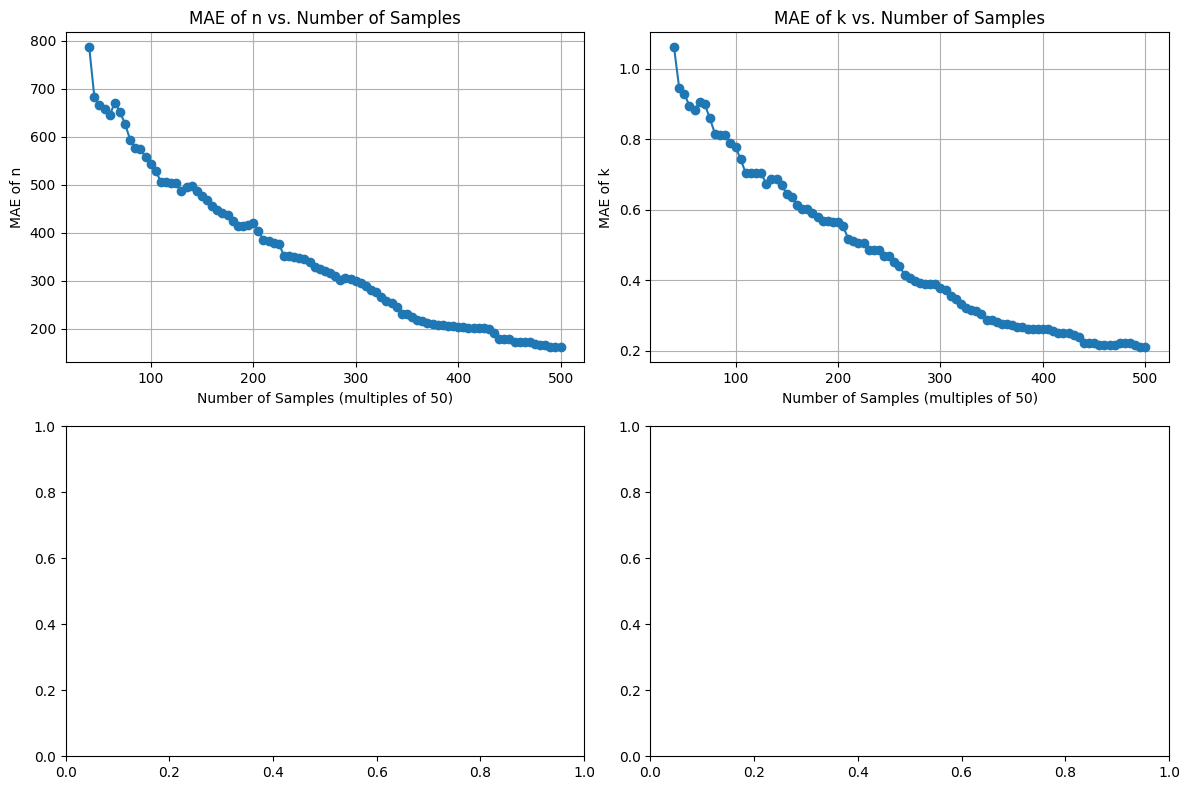

In [22]:
# Erdos - renyi
mae_results_erdos_renyi = compute_mae(res_erdos_renyi)
print(mae_results_erdos_renyi)
parameters_to_plot = ['n', 'd']
plot_mae(mae_results_erdos_renyi, parameters_to_plot, 'erdos-renyi')

In [23]:
list(res_erdos_renyi.keys())[-1]

500

In [24]:
mae_results_erdos_renyi

{1: {'cc': 0.0010024620396608796,
  'd': 2.2539035349440195,
  'H': 0.07023080452954032,
  'm': 9916.300116959066,
  'n': 2311.956023391812},
 5: {'cc': 0.001075150656035652,
  'd': 2.153625436610703,
  'H': 0.0665657016526333,
  'm': 4579.040584795318,
  'n': 1952.1164912280694},
 10: {'cc': 0.0010121753394236577,
  'd': 1.7032078499028245,
  'H': 0.05181337829377331,
  'm': 2365.948888888889,
  'n': 1463.5714619883042},
 15: {'cc': 0.0009484264181949711,
  'd': 1.5577737857422795,
  'H': 0.04600935237555095,
  'm': 2028.7614035087718,
  'n': 1049.8050292397659},
 20: {'cc': 0.000927597443361612,
  'd': 1.4853967942937554,
  'H': 0.043778525253954134,
  'm': 1371.0948538011698,
  'n': 1172.804561403509},
 25: {'cc': 0.0008556458782440863,
  'd': 1.3034847327376868,
  'H': 0.039023761390493315,
  'm': 1034.6219883040933,
  'n': 1079.797309941521},
 30: {'cc': 0.0007966096973809514,
  'd': 1.1607762473765886,
  'H': 0.03406967457674907,
  'm': 977.3318128654965,
  'n': 967.7000000000003

In [25]:
mae_results_erdos_renyi = compute_mae(res_erdos_renyi)
parameters_to_plot = ['n', 'd']
df_er = mae_to_dataframe(mae_results_erdos_renyi, parameters_to_plot, "ER-")
print(df_er)

                1            5            10           15           20   \
ER-n    2311.956023  1952.116491  1463.571462  1049.805029  1172.804561   
ER-d       2.253904     2.153625     1.703208     1.557774     1.485397   
ER-sum  2314.209927  1954.270117  1465.274670  1051.362803  1174.289958   

                25          30          35          40          45   ...  \
ER-n    1079.797310  967.700000  851.757427  786.373099  682.951696  ...   
ER-d       1.303485    1.160776    1.058446    1.060619    0.945884  ...   
ER-sum  1081.100795  968.860776  852.815873  787.433718  683.897580  ...   

               455         460         465         470         475  \
ER-n    173.436140  173.060936  172.326433  172.149825  167.937544   
ER-d      0.216098    0.215897    0.215897    0.215890    0.221677   
ER-sum  173.652238  173.276833  172.542330  172.365714  168.159221   

               480         485         490         495         500  
ER-n    167.204327  167.204327  162.665614  

In [26]:
def process_graph_results(graph_type, results, suffix=""):
    """
    Process results for a given graph type: compute MAE, plot it, and return a DataFrame.

    Parameters:
    - graph_type: str, e.g., 'erdos-renyi', 'chung-lu-pl', 'girg-1d'
    - results: dict, the raw results to compute MAE from
    - suffix: str, suffix for the plots names

    Returns:
    - DataFrame of MAE values
    """

    # Choose which parameters to use based on graph type
    parameter_map = {
        'erdos-renyi': ['n', 'd'],
        'chung-lu-pl': ['n', 'd', 'H'],
        'girg-1d': ['n', 'd', 'H', 'cc']
    }

    table_prefix_map = {
        'erdos-renyi': 'ER-',
        'chung-lu-pl': 'CL-',
        'girg-1d': 'G-'
    }

    if graph_type not in parameter_map:
        raise ValueError(f"Unsupported graph type: {graph_type}")

    parameters_to_plot = parameter_map[graph_type]
    mae_results = compute_mae(results)
    plot_mae(mae_results, parameters_to_plot, graph_type=graph_type +"_" + suffix)
    df = mae_to_dataframe(mae_results, parameters_to_plot, table_prefix_map[graph_type])

    return df


Plot saved to mae_per_candidate_num_erdos-renyi_.pdf


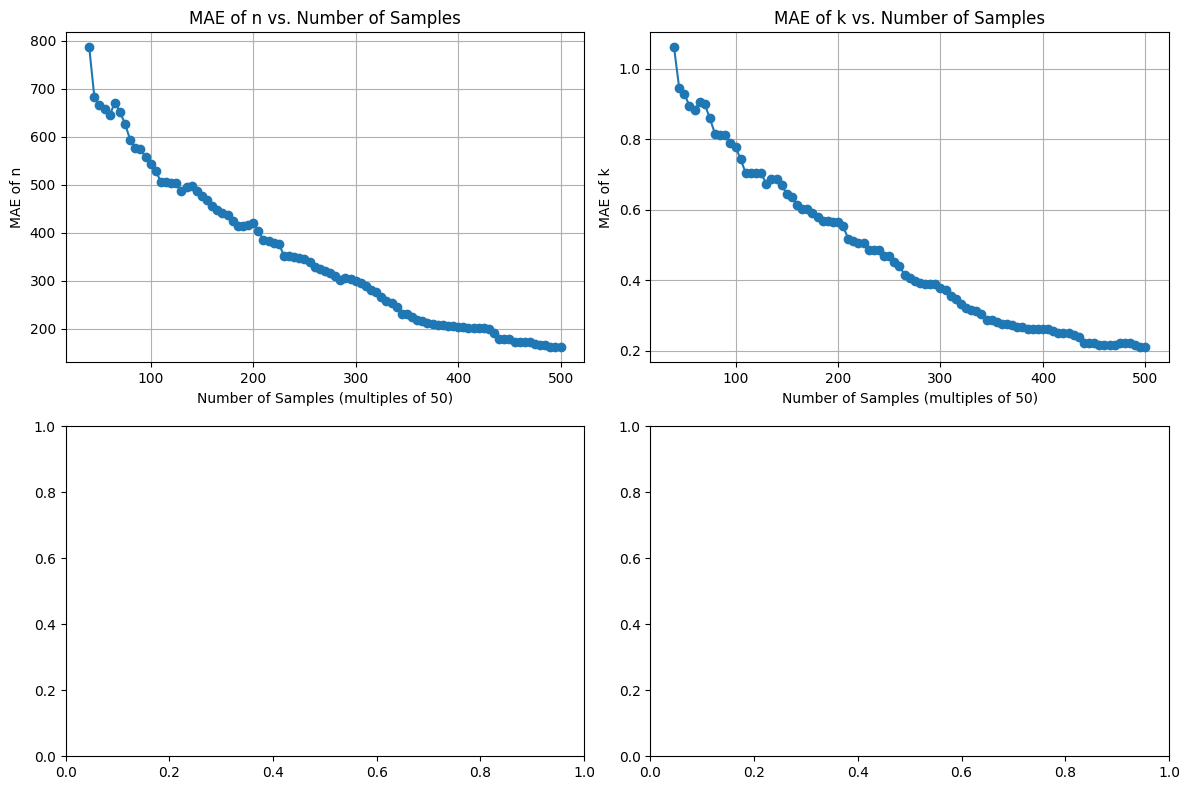

In [27]:
df_er = process_graph_results('erdos-renyi', res_erdos_renyi)

Plot saved to mae_per_candidate_num_chung-lu-pl_.pdf


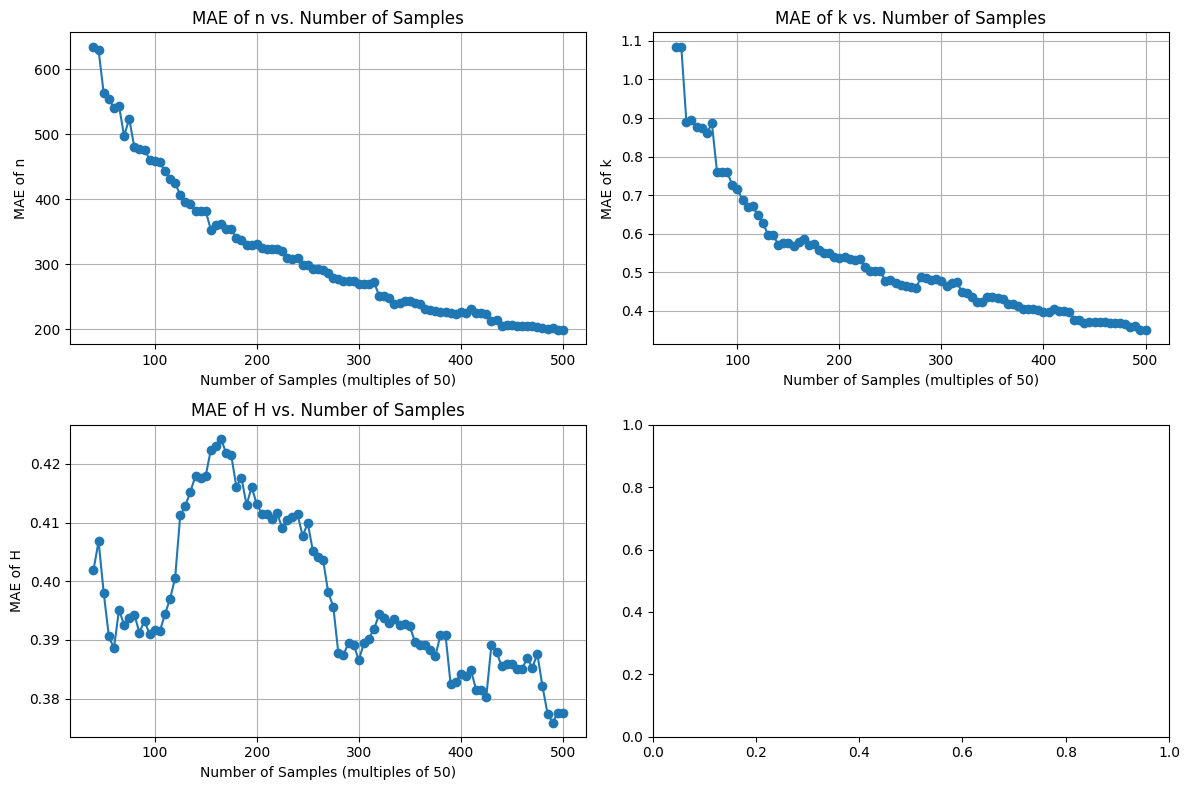

In [28]:
df_cl = process_graph_results('chung-lu-pl', res_chung_lu)

Plot saved to mae_per_candidate_num_girg-1d_.pdf


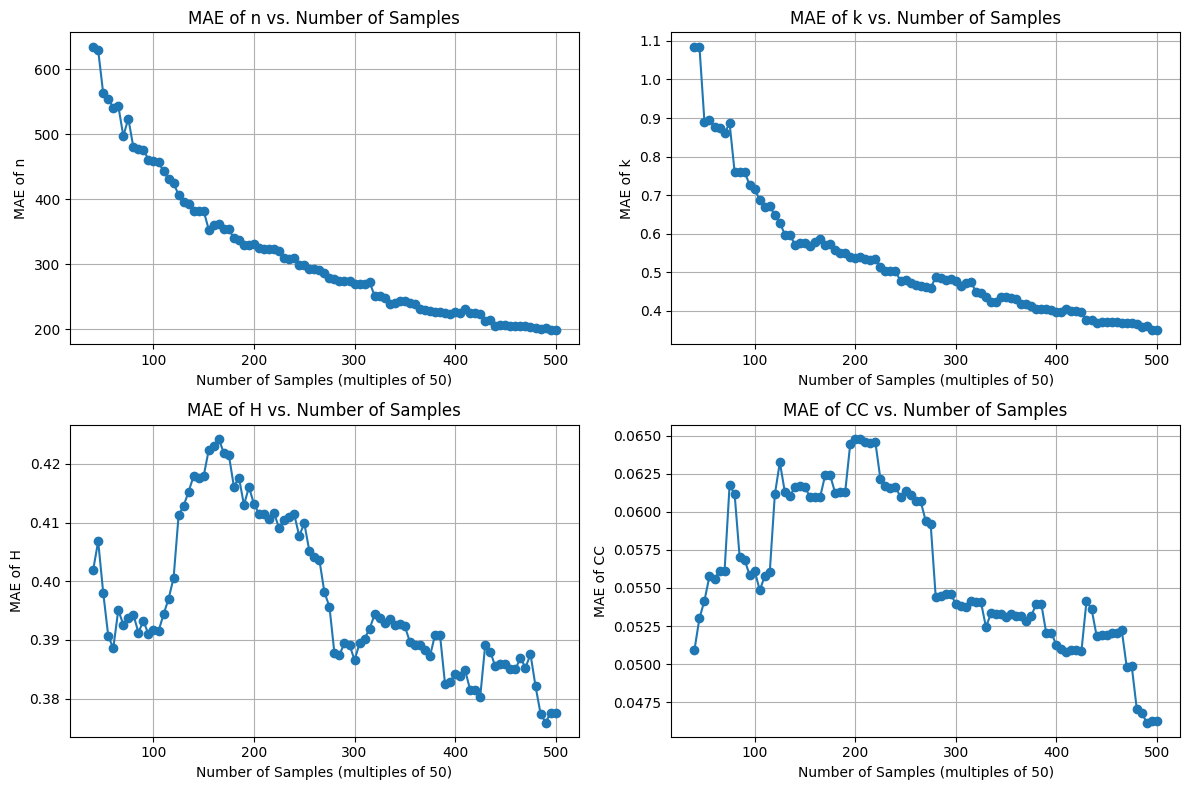

In [29]:
df_g = process_graph_results('girg-1d', res_chung_lu)

In [30]:
def save_merged_tables(df_er, df_cl, df_g, file_prefix=""):
  # Create the detailed result table
  # Merge the DataFrames row-wise (stack rows on top of each other)
  merged_df = pd.concat([df_er, df_cl, df_g], axis=0)
  merged_df = merged_df.sort_index()
  print(merged_df.to_string())
  merged_df.to_csv(os.path.join(output_dir, f"{file_prefix}_detailed_results.csv"))

  # Filter sum of the columns to create a shorter table
  selected_columns = [1] + list(range(50, 501, 50))
  filtered_df = merged_df[selected_columns]
  filtered_df.to_csv(os.path.join(output_dir, f"{file_prefix}_short_results.csv"))
  filtered_df

In [31]:
save_merged_tables(df_er, df_cl, df_g)

                1            5            10           15           20           25          30          35          40          45          50          55          60          65          70          75          80          85          90          95          100         105         110         115         120         125         130         135         140         145         150         155         160         165         170         175         180         185         190         195         200         205         210         215         220         225         230         235         240         245         250         255         260         265         270         275         280         285         290         295         300         305         310         315         320         325         330         335         340         345         350         355         360         365         370         375         380         385         390         395         400         405    